
# 16. Decision Analysis, Risk Communication, and Statistical Recommendations

Statistics becomes valuable only when it changes what a decision maker does. Up to this point in the course, we have studied uncertainty, estimation, predictive performance, regularization, and model evaluation. Those ideas matter because they shape how much confidence we should place in an analysis before turning it into action. But the final professional step is different from model fitting. It asks:

- What decision is actually on the table?
- What are the relevant actions and their consequences?
- How should uncertainty change the recommendation?
- How do we explain the recommendation differently to executives, operators, and technical reviewers?

We close the course by moving from forecast quality to decision quality. We return to the staffing-forecast setting from notebook 15 and ask a more realistic question: **given uncertainty about next week's overflow workload, how many temporary contractor hours should operations activate now?**

That question is not answered by RMSE alone. It requires a loss function, an understanding of downside risk, and a communication style that is honest about uncertainty without becoming evasive. In other words, it is exactly the kind of problem where statistical thinking becomes decision science.



## Learning Objectives

After working through this lecture, you should be able to:

- translate a predictive model output into a decision problem with explicit action choices and costs;
- distinguish point predictions from predictive distributions and explain why the latter matter for high-stakes decisions;
- compare candidate actions using expected cost, tail risk, and event probabilities alongside a single average;
- understand the expected value of perfect information (EVPI) as an upper bound on how much additional certainty could be worth;
- formulate recommendation rules that combine model output with operational guardrails;
- communicate the same quantitative result appropriately to executive, operational, and technical audiences;
- articulate why good statistical work ends with a recommendation structure, a fitted model and a recommendation structure.


## Mathematical Core: From Uncertainty to Action

A statistical recommendation needs an action set, uncertainty about outcomes, and a cost or utility model. Let `a` be an action and `Y` be an uncertain future outcome. If smaller cost is better, the expected cost of an action is

$$
EC(a) = \mathbb{E}\left[C(a, Y) \mid \text{data}\right].
$$

A risk-neutral decision rule chooses

$$
a^* = \arg\min_{a \in \mathcal{A}} EC(a).
$$

In simulation, this expectation is approximated with predictive draws `Y^(1), ..., Y^(R)`:

$$
\widehat{EC}(a)
= \frac{1}{R}\sum_{r=1}^{R} C\left(a, Y^{(r)}\right).
$$

Decision makers often need risk summaries in addition to expected cost:

$$
q_{0.90}\left(C(a, Y)\right),
\qquad
P\left(C(a, Y) > c\right),
\qquad
P\left(\text{shortage under } a\right).
$$

The expected value of perfect information compares the cost of acting under uncertainty with the cost we would pay if the future outcome were known before acting:

$$
EVPI = \min_{a} \mathbb{E}[C(a, Y)]
- \mathbb{E}\left[\min_{a} C(a, Y)\right].
$$

This is the mathematical bridge from statistical uncertainty to recommendation quality: the best action has the strongest risk-adjusted decision profile.

In [1]:
# Load the libraries and notebook settings used in the examples below.
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'notebooks' / '_shared' / 'display.py').exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio root so shared notebook helpers import reliably.
    
    Parameters:
        start: Starting path for the upward project-root search.
    
    Returns:
        A `Path` pointing to the nearest portfolio root that contains `notebooks/_shared`; if no such parent is found, the original starting path is returned.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.display import smart_display

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.float_format', lambda x: f"{x:0.3f}")
np.random.seed(16)


def make_staffing_forecast_data(n=2600, seed=15):
    """
    Construct the staffing forecast data object used in this lecture.
    
    Parameters:
        n: Number of observations, rows, or simulated units to generate.
        seed: Random seed used to make the simulation or resampling reproducible.
    
    Returns:
        A pandas DataFrame of weekly staffing-forecast rows with workload drivers, noise variables, and next-week overflow hours.
    
    Idea:
        Construct a staffing-demand dataset with trend, seasonality, and workload drivers so validation reflects realistic forecasting pressure.
    """
    rng = np.random.default_rng(seed)

    demand_index = rng.normal(0, 1, n)
    workforce_index = rng.normal(0, 1, n)
    process_fragility = rng.normal(0, 1, n)

    incoming_cases = np.clip(220 + 48 * demand_index + 10 * process_fragility + rng.normal(0, 16, n), 90, 420)
    backlog_hours = np.clip(60 + 16 * demand_index - 11 * workforce_index + 12 * process_fragility + rng.normal(0, 9, n), 8, 180)
    complex_case_share = np.clip(0.25 + 0.06 * demand_index + 0.08 * process_fragility + rng.normal(0, 0.05, n), 0.05, 0.75)
    automation_rate = np.clip(0.56 - 0.05 * process_fragility + 0.05 * workforce_index + rng.normal(0, 0.05, n), 0.05, 0.95)
    analyst_capacity = np.clip(165 + 24 * workforce_index - 6 * demand_index + rng.normal(0, 11, n), 90, 245)
    queue_variability = np.clip(0.18 + 0.08 * np.abs(demand_index) + 0.08 * process_fragility + rng.normal(0, 0.03, n), 0.04, 0.70)
    holiday_week = rng.binomial(1, 1 / (1 + np.exp(-(-1.4 + 0.45 * demand_index))))
    enterprise_share = np.clip(0.34 + 0.05 * process_fragility + rng.normal(0, 0.04, n), 0.08, 0.80)
    prior_escalations = np.clip(rng.poisson(lam=np.exp(1.05 + 0.22 * process_fragility + 0.12 * demand_index)), 0, 25)

    case_pressure = incoming_cases / analyst_capacity
    noise_1 = rng.normal(0, 1, n)
    noise_2 = rng.normal(0, 1, n)
    noise_3 = rng.uniform(-1, 1, n)

    signal = (
        16
        + 0.11 * (incoming_cases - 220)
        + 0.43 * backlog_hours
        + 72 * complex_case_share
        - 0.18 * analyst_capacity
        - 26 * automation_rate
        + 18 * queue_variability
        + 8 * holiday_week
        + 12 * enterprise_share
        + 0.95 * prior_escalations
        + 34 * np.maximum(case_pressure - 1.05, 0) ** 2
        + 42 * complex_case_share * queue_variability
        - 12 * automation_rate * enterprise_share
    )

    noise_sd = 7 + 5 * queue_variability + 5 * complex_case_share + 2 * holiday_week
    overflow_hours_next_week = np.clip(signal + rng.normal(0, noise_sd, n), 0.5, None)

    return pd.DataFrame(
        {
            'incoming_cases': incoming_cases,
            'backlog_hours': backlog_hours,
            'complex_case_share': complex_case_share,
            'automation_rate': automation_rate,
            'analyst_capacity': analyst_capacity,
            'queue_variability': queue_variability,
            'holiday_week': holiday_week,
            'enterprise_share': enterprise_share,
            'prior_escalations': prior_escalations,
            'case_pressure': case_pressure,
            'noise_1': noise_1,
            'noise_2': noise_2,
            'noise_3': noise_3,
            'overflow_hours_next_week': overflow_hours_next_week,
        }
    )


def make_lasso_model(alpha=0.025):
    """
    Construct the lasso model object used in this lecture.
    
    Parameters:
        alpha: Significance level, regularization strength, or model parameter as defined by the calling cell.
    
    Returns:
        A scikit-learn polynomial-feature pipeline with lasso regularization using the requested `alpha` value.
    
    Idea:
        Use L1 regularization to shrink weak predictors and perform implicit feature selection when the model space is larger than the signal.
    """
    return Pipeline([
        ('poly', PolynomialFeatures(degree=3, include_bias=False)),
        ('scale', StandardScaler()),
        ('model', Lasso(alpha=alpha, max_iter=100000, tol=1e-3)),
    ])


def rmse(y_true, y_pred):
    """
    Compute root mean squared error between observed and predicted values.
    
    Parameters:
        y_true: Observed outcome values.
        y_pred: Predicted outcome values.
    
    Returns:
        The root mean squared error as a single numeric value on the same outcome scale as the original target.
    
    Idea:
        Measure forecast error in the original outcome units so model performance can be interpreted in operational terms.
    """
    return np.sqrt(mean_squared_error(y_true, y_pred))


def regression_scores(y_true, y_pred):
    """
    Compute the regression scores quantity used in the statistical or decision-science workflow.
    
    Parameters:
        y_true: Observed outcome values.
        y_pred: Predicted outcome values.
    
    Returns:
        A dictionary of predictive performance metrics, including RMSE, MAE, and R-squared.
    
    Idea:
        Translate predictions into comparable error metrics so model choice is tied to operational forecast accuracy.
    """
    return {
        'rmse': rmse(y_true, y_pred),
        'mae': mean_absolute_error(y_true, y_pred),
        'r2': r2_score(y_true, y_pred),
    }


def staffing_action_cost(overflow_draws, contractor_hours, hourly_cost=88, shortage_cost=235, fixed_activation=450, severe_shortage_cutoff=18, severe_shortage_penalty=5000):
    """
    Compute the staffing action cost quantity used in the statistical or decision-science workflow.
    
    Parameters:
        overflow_draws: Number of draws or grid points used in the numerical approximation.
        contractor_hours: Decision-scale quantity used in the cost, value, or operational calculation.
        hourly_cost: Decision-scale quantity used in the cost, value, or operational calculation.
        shortage_cost: Decision-scale quantity used in the cost, value, or operational calculation.
        fixed_activation: Input used by `fixed_activation` in this helper.
        severe_shortage_cutoff: Decision or statistical threshold used to define the target, interval, or rule.
        severe_shortage_penalty: Additional penalty for severe shortage scenarios.
    
    Returns:
        The `staffing_action_cost` result, expressed in the specific form needed by the subsequent notebook cells.
    
    Idea:
        Convert staffing choices into expected costs, making the loss function behind the recommendation explicit.
    """
    overflow_draws = np.asarray(overflow_draws)
    shortage = np.maximum(overflow_draws - contractor_hours, 0)
    severe_shortage = (shortage > severe_shortage_cutoff).astype(float)
    activation = 0 if contractor_hours == 0 else fixed_activation
    return activation + hourly_cost * contractor_hours + shortage_cost * shortage + severe_shortage_penalty * severe_shortage


def summarize_action(overflow_draws, contractor_hours):
    """
    Summarize action into a compact table or record.
    
    Parameters:
        overflow_draws: Number of draws or grid points used in the numerical approximation.
        contractor_hours: Decision-scale quantity used in the cost, value, or operational calculation.
    
    Returns:
        A dictionary of decision metrics for one staffing action, including expected cost, quantiles, shortage probability, and guardrail risk.
    
    Idea:
        Combine expected cost, risk, and operational implications into an action summary that supports a recommendation.
    """
    realized_cost = staffing_action_cost(overflow_draws, contractor_hours)
    shortage = np.maximum(overflow_draws - contractor_hours, 0)
    return {
        'contractor_hours': contractor_hours,
        'expected_cost': realized_cost.mean(),
        'median_cost': np.median(realized_cost),
        'p90_cost': np.quantile(realized_cost, 0.90),
        'p95_cost': np.quantile(realized_cost, 0.95),
        'prob_any_shortage': np.mean(shortage > 0),
        'prob_severe_shortage': np.mean(shortage > 18),
        'expected_uncovered_hours': shortage.mean(),
        'prob_excess_buffer_gt_15': np.mean(contractor_hours - overflow_draws > 15),
    }


## 1. Forecast Engine and Decision Context

We use the same synthetic staffing environment introduced in notebook 15. The target is **next-week overflow labor hours**, and the predictive engine is a cubic lasso regression, which performed best in the previous notebook on validation, repeated cross-validation, and the final test set.

The operational decision is simple to state but not simple to solve:

- activate no temporary analysts,
- activate a modest surge block,
- activate a larger surge block,
- or prepare for a heavy overflow week.

Every choice costs something. Contractor hours are expensive even when unused, but uncovered overflow can be much more expensive because it triggers overtime, backlogs, SLA credits, and customer dissatisfaction. The right action therefore depends on the **distribution** of possible overflow, its average and its tail behavior.


### Dataset and Experiment Design

The dataset is the same synthetic weekly staffing panel used in notebook 15. Each row describes a future planning week with demand, backlog, case complexity, automation coverage, analyst capacity, holiday disruption, enterprise mix, prior escalations, and noise variables. The target is next-week overflow labor hours.

The experiment has three layers. First, we fit the previously selected cubic lasso forecast model. Second, we build a predictive distribution for one stressful upcoming week by combining bootstrap refits with out-of-fold residual draws. Third, we evaluate staffing actions under an explicit cost model. This turns the modeling problem into a decision problem.

That structure is deliberate. A point forecast can say what is most likely, but a staffing recommendation must also ask what happens if the week is worse than expected. The dataset and experiment are built to connect forecast uncertainty, shortage risk, cost, and communication into one recommendation workflow.

In [2]:
# Fit the statistical or machine-learning model used for this comparison.
staffing_df = make_staffing_forecast_data(n=2600, seed=15)
feature_columns = [
    'incoming_cases',
    'backlog_hours',
    'complex_case_share',
    'automation_rate',
    'analyst_capacity',
    'queue_variability',
    'holiday_week',
    'enterprise_share',
    'prior_escalations',
    'case_pressure',
    'noise_1',
    'noise_2',
    'noise_3',
]
target_column = 'overflow_hours_next_week'


development_df, test_df = train_test_split(staffing_df, test_size=0.25, random_state=15)
X_dev = development_df[feature_columns]
y_dev = development_df[target_column]
X_test = test_df[feature_columns]
y_test = test_df[target_column]

forecast_model = make_lasso_model(alpha=0.025)
forecast_model.fit(X_dev, y_dev)
test_pred = forecast_model.predict(X_test)
forecast_scores = regression_scores(y_test, test_pred)

model_quality = pd.DataFrame(
    {
        'dataset': ['Held-out test set'],
        'rmse_hours': [forecast_scores['rmse']],
        'mae_hours': [forecast_scores['mae']],
        'r2': [forecast_scores['r2']],
    }
)
smart_display(model_quality)

display(
    Markdown(
        f"The forecasting engine has a held-out **RMSE of {forecast_scores['rmse']:.2f} hours** and **MAE of {forecast_scores['mae']:.2f} hours**. "
        "That is strong enough to support planning, but not strong enough to justify certainty. Any recommendation built from this model must still respect residual uncertainty."
    )
)


,dataset,rmse_hours,mae_hours,r2
0,Held-out test set,9.717,7.600,0.940


The forecasting engine has a held-out **RMSE of 9.72 hours** and **MAE of 7.60 hours**. That is strong enough to support planning, but not strong enough to justify certainty. Any recommendation built from this model must still respect residual uncertainty.


### Action Menu

| Policy | Contractor Hours Activated | Operational Interpretation |
|---|---:|---|
| `No surge` | 0 | Accept the base staffing plan and handle overflow reactively. |
| `Light surge` | 20 | Add a modest contractor block while keeping spend low. |
| `Moderate surge` | 40 | Prepare for a meaningfully stressed week without going fully defensive. |
| `Heavy surge` | 60 | Protect strongly against service deterioration at materially higher cost. |
| `Maximum surge` | 80 | Buy a large safety margin to minimize shortage risk. |



## 2. A Specific Upcoming Week Scenario

To keep the notebook concrete, we evaluate one plausible upcoming week that is operationally stressful but not apocalyptic. Demand is elevated, backlog is already present, capacity is somewhat tight, and the week includes a holiday disruption. This is exactly the kind of situation where a point forecast is not enough: leadership needs to know whether the upper tail of the risk justifies more protective staffing.


In [3]:
# Build a summary table that supports the interpretation in the surrounding notes.
future_week = pd.DataFrame(
    [
        {
            'incoming_cases': staffing_df['incoming_cases'].quantile(0.70),
            'backlog_hours': staffing_df['backlog_hours'].quantile(0.65),
            'complex_case_share': staffing_df['complex_case_share'].quantile(0.65),
            'automation_rate': staffing_df['automation_rate'].quantile(0.35),
            'analyst_capacity': staffing_df['analyst_capacity'].quantile(0.35),
            'queue_variability': staffing_df['queue_variability'].quantile(0.65),
            'holiday_week': 1,
            'enterprise_share': staffing_df['enterprise_share'].quantile(0.60),
            'prior_escalations': int(round(staffing_df['prior_escalations'].quantile(0.65))),
            'noise_1': 0.0,
            'noise_2': 0.0,
            'noise_3': 0.0,
        }
    ]
)
future_week['case_pressure'] = future_week['incoming_cases'] / future_week['analyst_capacity']

scenario_table = pd.DataFrame(
    {
        'variable': future_week.columns,
        'value': future_week.iloc[0].values,
    }
)
smart_display(scenario_table)

point_forecast = float(forecast_model.predict(future_week[feature_columns])[0])

display(
    Markdown(
        f"The model's point forecast for this week is **{point_forecast:.1f} overflow hours**. "
        "That puts the team in a genuinely difficult middle zone: too much demand to ignore, but not so much that the staffing answer is automatic. "
        "We therefore need a predictive distribution, a point estimate and an uncertainty description."
    )
)


,variable,value
0,incoming_cases,248.694
1,backlog_hours,70.221
2,complex_case_share,0.294
3,automation_rate,0.525
4,analyst_capacity,154.522
5,queue_variability,0.278
6,holiday_week,1.000
7,enterprise_share,0.357
8,prior_escalations,3.000
9,noise_1,0.000


The model's point forecast for this week is **61.4 overflow hours**. That puts the team in a genuinely difficult middle zone: too much demand to ignore, but not so much that the staffing answer is automatic. We therefore need a predictive distribution, a point estimate and an uncertainty description.


## 3. Build a Predictive Distribution

A good recommendation should reflect at least two kinds of uncertainty:

1. **model uncertainty**: if we refit the model on another plausible historical sample, the predicted mean may shift;
2. **irreducible noise**: even with the same inputs, operational outcomes vary because not every driver is observed.

We approximate those ingredients in a practical way:

- use bootstrap refits on the development sample to vary the fitted prediction;
- use out-of-fold residuals from cross-validation to represent unresolved week-to-week noise.

This is one transparent way to produce a predictive distribution for decision analysis.


,quantity,hours
0,Point forecast,61.445
1,Bootstrap mean forecast,61.304
2,Predictive median,61.378
3,Predictive 10th percentile,49.343
4,Predictive 90th percentile,73.920
5,Predictive 95th percentile,78.065


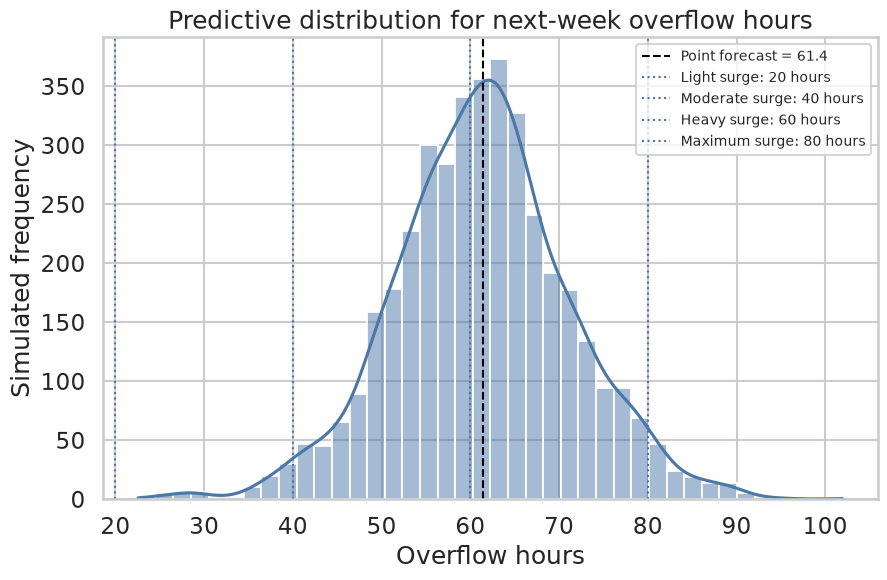

The predictive distribution is centered around **61.3 hours**, but the **90th percentile is 73.9 hours**. That spread is the reason the staffing choice cannot be reduced to the point forecast alone.

In [4]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
cv = KFold(n_splits=6, shuffle=True, random_state=16)
oof_pred = cross_val_predict(make_lasso_model(alpha=0.025), X_dev, y_dev, cv=cv, n_jobs=None)
oof_residuals = y_dev.to_numpy() - oof_pred

rng = np.random.default_rng(16)
bootstrap_means = []
for _ in range(80):
    sample_idx = rng.choice(len(X_dev), size=len(X_dev), replace=True)
    X_boot = X_dev.iloc[sample_idx]
    y_boot = y_dev.iloc[sample_idx]
    model_boot = make_lasso_model(alpha=0.025)
    model_boot.fit(X_boot, y_boot)
    bootstrap_means.append(float(model_boot.predict(future_week[feature_columns])[0]))

bootstrap_means = np.asarray(bootstrap_means)
residual_draws = rng.choice(oof_residuals, size=4000, replace=True)
mean_draws = rng.choice(bootstrap_means, size=4000, replace=True)
predictive_draws = np.clip(mean_draws + residual_draws, 0, None)

uncertainty_summary = pd.DataFrame(
    {
        'quantity': ['Point forecast', 'Bootstrap mean forecast', 'Predictive median', 'Predictive 10th percentile', 'Predictive 90th percentile', 'Predictive 95th percentile'],
        'hours': [
            point_forecast,
            bootstrap_means.mean(),
            np.median(predictive_draws),
            np.quantile(predictive_draws, 0.10),
            np.quantile(predictive_draws, 0.90),
            np.quantile(predictive_draws, 0.95),
        ],
    }
)
smart_display(uncertainty_summary)

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(predictive_draws, bins=40, kde=True, color='#4C78A8', ax=ax)
ax.axvline(point_forecast, color='black', linestyle='--', linewidth=1.5, label=f'Point forecast = {point_forecast:.1f}')
for hours, label in [(20, 'Light surge'), (40, 'Moderate surge'), (60, 'Heavy surge'), (80, 'Maximum surge')]:
    ax.axvline(hours, linestyle=':', linewidth=1.5, label=f'{label}: {hours} hours')
ax.set_title('Predictive distribution for next-week overflow hours')
ax.set_xlabel('Overflow hours')
ax.set_ylabel('Simulated frequency')
ax.legend(fontsize=10)
plt.show()

display(
    Markdown(
        f"The predictive distribution is centered around **{np.mean(predictive_draws):.1f} hours**, but the **90th percentile is {np.quantile(predictive_draws, 0.90):.1f} hours**. "
        "That spread is the reason the staffing choice cannot be reduced to the point forecast alone."
    )
)



## 4. Evaluate Candidate Actions Under a Cost Model

We now impose a simple but explicit cost structure:

- each contractor hour costs **$88**;
- activating any contractor block incurs a fixed coordination cost of **$450**;
- each uncovered overflow hour costs **$235** in overtime, service degradation, and downstream recovery effort;
- if uncovered overflow exceeds **18 hours**, we add a **$5,000 severe-shortage penalty** to represent elevated SLA and customer-risk consequences.

These numbers are illustrative, not universal. Their purpose is to force the decision logic into the open. Once a cost structure is explicit, disagreements can move from vague instincts to concrete assumptions.


,policy,contractor_hours,expected_cost,p90_cost,p95_cost,prob_any_shortage,prob_severe_shortage,expected_uncovered_hours,prob_excess_buffer_gt_15
3,Heavy surge,60,7053.082,9001.167,14975.301,0.558,0.052,4.524,0.048
4,Maximum surge,80,7523.535,7490.000,7490.000,0.033,0.000,0.137,0.667
2,Moderate surge,40,12227.051,16941.167,17915.301,0.982,0.644,21.424,0.001
1,Light surge,20,16865.216,19881.167,20855.301,1.000,0.988,41.336,0.000
0,No surge,0,19413.966,22371.167,23345.301,1.000,1.000,61.336,0.000


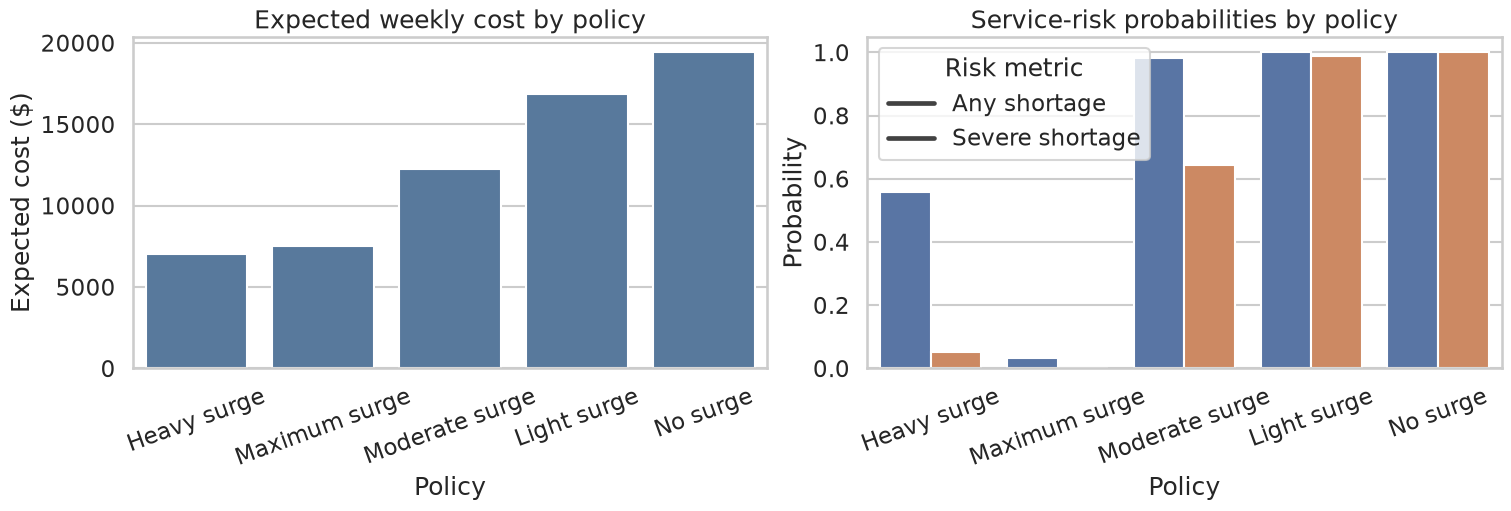

A purely expected-cost view favors **Heavy surge (60 hours)**, whereas a more conservative rule favors **Maximum surge (80 hours)** because it reduces tail risk at only a modest expected-cost premium.

In [5]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
action_hours = [0, 20, 40, 60, 80]
action_labels = {
    0: 'No surge',
    20: 'Light surge',
    40: 'Moderate surge',
    60: 'Heavy surge',
    80: 'Maximum surge',
}

action_rows = []
for hours in action_hours:
    summary = summarize_action(predictive_draws, contractor_hours=hours)
    summary['policy'] = action_labels[hours]
    action_rows.append(summary)

action_table = pd.DataFrame(action_rows).sort_values('expected_cost')
smart_display(action_table[['policy', 'contractor_hours', 'expected_cost', 'p90_cost', 'p95_cost', 'prob_any_shortage', 'prob_severe_shortage', 'expected_uncovered_hours', 'prob_excess_buffer_gt_15']])

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

sns.barplot(data=action_table, x='policy', y='expected_cost', ax=axes[0], color='#4C78A8')
axes[0].set_title('Expected weekly cost by policy')
axes[0].set_xlabel('Policy')
axes[0].set_ylabel('Expected cost ($)')
axes[0].tick_params(axis='x', rotation=20)

risk_plot = action_table.melt(
    id_vars=['policy'],
    value_vars=['prob_any_shortage', 'prob_severe_shortage'],
    var_name='risk_metric',
    value_name='probability',
)
sns.barplot(data=risk_plot, x='policy', y='probability', hue='risk_metric', ax=axes[1])
axes[1].set_title('Service-risk probabilities by policy')
axes[1].set_xlabel('Policy')
axes[1].set_ylabel('Probability')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(title='Risk metric', labels=['Any shortage', 'Severe shortage'])

plt.show()

risk_neutral_choice = action_table.sort_values('expected_cost').iloc[0]

min_expected = action_table['expected_cost'].min()
conservative_candidates = action_table[action_table['expected_cost'] <= min_expected * 1.12].copy()
conservative_choice = conservative_candidates.sort_values(['prob_severe_shortage', 'p90_cost', 'expected_cost']).iloc[0]

if conservative_choice['policy'] == risk_neutral_choice['policy']:
    decision_message = (
        f"Under both the risk-neutral and conservative rules used here, **{risk_neutral_choice['policy']} ({int(risk_neutral_choice['contractor_hours'])} hours)** is preferred."
    )
else:
    decision_message = (
        f"A purely expected-cost view favors **{risk_neutral_choice['policy']} ({int(risk_neutral_choice['contractor_hours'])} hours)**, "
        f"whereas a more conservative rule favors **{conservative_choice['policy']} ({int(conservative_choice['contractor_hours'])} hours)** because it reduces tail risk at only a modest expected-cost premium."
    )

display(Markdown(decision_message))



The distinction between these two decision styles is central to professional recommendation writing. A risk-neutral decision maker asks, "Which option minimizes expected cost?" A more conservative decision maker asks, "How much tail risk am I willing to absorb in exchange for lower expected spend?" Statistics does not erase that governance choice. It clarifies it.



## 5. Expected Value of Perfect Information

A natural next question is whether additional information would be worth paying for. If we somehow knew the exact overflow hours before choosing a staffing action, we could tailor the contractor block perfectly to the realized week.

The **expected value of perfect information (EVPI)** measures the maximum amount a decision maker should be willing to pay for that impossible level of certainty. It is an upper bound on the value of better forecasts, faster monitoring, or extra analysis.


In [6]:
# Build a summary table that supports the interpretation in the surrounding notes.
realized_cost_matrix = np.column_stack([
    staffing_action_cost(predictive_draws, contractor_hours=hours) for hours in action_hours
])
current_best_expected_cost = realized_cost_matrix.mean(axis=0).min()
perfect_information_expected_cost = np.min(realized_cost_matrix, axis=1).mean()
evpi = current_best_expected_cost - perfect_information_expected_cost

voi_table = pd.DataFrame(
    {
        'quantity': [
            'Best current expected weekly cost',
            'Expected weekly cost with perfect information',
            'Expected value of perfect information (EVPI)',
        ],
        'dollars': [current_best_expected_cost, perfect_information_expected_cost, evpi],
    }
)
smart_display(voi_table)

display(
    Markdown(
        f"The weekly **EVPI is about ${evpi:,.0f}**. That means even perfect knowledge of next week's overflow would only be worth that amount on average for this decision problem. "
        "Any extra monitoring or forecasting effort should therefore be judged against that upper bound, not against an abstract desire for certainty."
    )
)


,quantity,dollars
0,Best current expected weekly cost,7053.082110
1,Expected weekly cost with perfect information,6381.423831
2,Expected value of perfect information (EVPI),671.658279


The weekly **EVPI is about $672**. That means even perfect knowledge of next week's overflow would only be worth that amount on average for this decision problem. Any extra monitoring or forecasting effort should therefore be judged against that upper bound, not against an abstract desire for certainty.


## 6. Recommendation Design and Guardrails

A recommendation should rarely be a naked action without conditions. Good statistical decision support includes **guardrails** that tell the organization when to act, what to watch, and how to revise course.

For this staffing problem, useful guardrails might include:

- a forecast threshold above which surge staffing becomes the default;
- a downside-risk threshold that triggers escalation even when expected cost is close;
- a same-day review if real inflow exceeds a certain fraction of the forecast;
- a post-week audit comparing realized overflow to the predictive interval.

Those guardrails turn one recommendation into a repeatable operating policy.


In [7]:
# Build a summary table that supports the interpretation in the surrounding notes.
recommended_policy = conservative_choice if conservative_choice['prob_severe_shortage'] < risk_neutral_choice['prob_severe_shortage'] else risk_neutral_choice
recommended_hours = int(recommended_policy['contractor_hours'])
recommended_name = recommended_policy['policy']
max_available_hours = max(action_hours)

if recommended_hours < max_available_hours:
    median_trigger_rule = f"{recommended_hours + 15} overflow hours"
    inflow_trigger_rule = f"{future_week.iloc[0]['incoming_cases'] * 1.08:0.0f} incoming cases"
    median_trigger_reason = 'Provides a simple threshold for moving from the current plan to a more defensive surge tier.'
    inflow_trigger_reason = 'Creates an operational override when live demand arrives hotter than expected.'
else:
    median_trigger_rule = f"{recommended_hours} overflow hours plus overtime escalation"
    inflow_trigger_rule = f"{future_week.iloc[0]['incoming_cases'] * 1.08:0.0f} incoming cases with management overtime approval"
    median_trigger_reason = 'Because the base recommendation already uses the highest listed surge tier, any further deterioration should trigger contingency actions outside the standard menu.'
    inflow_trigger_reason = 'Clarifies what to do when demand outruns even the most defensive scheduled staffing option.'

trigger_table = pd.DataFrame(
    {
        'guardrail': [
            'Default action for this week',
            'Escalate further if forecast median rises above',
            'Escalate further if same-day inflow exceeds',
            'Review model performance if realized overflow falls outside',
        ],
        'rule': [
            f'{recommended_name} ({recommended_hours} contractor hours)',
            median_trigger_rule,
            inflow_trigger_rule,
            'the 10th-90th percentile predictive range',
        ],
        'why_it_matters': [
            'Sets the initial staffing posture before the week begins.',
            median_trigger_reason,
            inflow_trigger_reason,
            'Maintains a feedback loop so the forecast engine does not become stale or overtrusted.',
        ],
    }
)
smart_display(trigger_table)


,guardrail,rule,why_it_matters
0,Default action for this week,Maximum surge (80 contractor hours),Sets the initial staffing posture before the week begins.
1,Escalate further if forecast median rises above,80 overflow hours plus overtime escalation,"Because the base recommendation already uses the highest listed surge tier, any further deterioration should trigger contingency actions outside the standard menu."
2,Escalate further if same-day inflow exceeds,269 incoming cases with management overtime approval,Clarifies what to do when demand outruns even the most defensive scheduled staffing option.
3,Review model performance if realized overflow falls outside,the 10th-90th percentile predictive range,Maintains a feedback loop so the forecast engine does not become stale or overtrusted.



## 7. Same Analysis, Different Audience

One of the most underrated statistical skills is changing the communication surface without changing the analytical truth. The executive, the operations manager, and the technical reviewer do not need different conclusions. They need different emphases.

- **Executive audience:** focus on the recommended action, cost range, downside protection, and decision timing.
- **Operations audience:** focus on thresholds, contingency triggers, and staffing mechanics.
- **Technical audience:** focus on model quality, uncertainty construction, assumptions, and failure modes.

Below are three example recommendation formats built from the same quantitative result.


In [8]:
# Translate the computed evidence into a decision-oriented summary.
executive_brief = f"""
### Executive Brief

Recommend **{recommended_name.lower()}** by activating **{recommended_hours} contractor hours** for next week.

- Forecasted overflow is centered around **{np.mean(predictive_draws):.1f} hours**, with a 90th-percentile scenario near **{np.quantile(predictive_draws, 0.90):.1f} hours**.
- This policy yields an expected weekly cost of roughly **${recommended_policy['expected_cost']:,.0f}**, while keeping the severe-shortage risk near **{recommended_policy['prob_severe_shortage']:.1%}**.
- The recommendation should be revisited only if same-day inflow materially exceeds the current plan assumptions.
"""

display(Markdown(executive_brief))



### Executive Brief

Recommend **maximum surge** by activating **80 contractor hours** for next week.

- Forecasted overflow is centered around **61.3 hours**, with a 90th-percentile scenario near **73.9 hours**.
- This policy yields an expected weekly cost of roughly **$7,524**, while keeping the severe-shortage risk near **0.0%**.
- The recommendation should be revisited only if same-day inflow materially exceeds the current plan assumptions.


The executive brief turns the predictive distribution into a concrete action. It does not simply report the forecasted overflow; it names the recommended surge tier, expected weekly cost, and severe-shortage risk under the selected policy.

That is the standard this lecture is aiming for. A written for stakeholders statistical recommendation should connect uncertainty to an action, explain when the action should be revisited, and spare the reader from inferring the decision from a model output.


In [9]:
# Compute the quantities used by the next explanation, table, or figure.
if recommended_hours < max_available_hours:
    first_trigger = (
        f"1. If live incoming cases exceed **{future_week.iloc[0]['incoming_cases'] * 1.08:0.0f}**, "
        'move to the next surge tier.'
    )
else:
    first_trigger = (
        f"1. If live incoming cases exceed **{future_week.iloc[0]['incoming_cases'] * 1.08:0.0f}**, keep the full surge block in place "
        'and activate overtime or backlog-deferral contingencies; there is no higher standard surge tier available.'
    )

operations_note = f"""
### Operations Note

Plan next week using **{recommended_name.lower()}** (**{recommended_hours} contractor hours**).

Operational triggers:

{first_trigger}
2. If backlog is still above **{future_week.iloc[0]['backlog_hours'] * 1.10:0.0f} hours** by midweek, keep contractor coverage in place.
3. If early-week conditions track below plan, do **not** immediately cancel coverage unless the downside risk has clearly collapsed; the model still assigns meaningful upper-tail mass to overload.

The main statistical reason for this policy is not the point forecast alone. It is the combination of expected overflow and the nontrivial right tail of the predictive distribution.
"""

display(Markdown(operations_note))



### Operations Note

Plan next week using **maximum surge** (**80 contractor hours**).

Operational triggers:

1. If live incoming cases exceed **269**, keep the full surge block in place and activate overtime or backlog-deferral contingencies; there is no higher standard surge tier available.
2. If backlog is still above **77 hours** by midweek, keep contractor coverage in place.
3. If early-week conditions track below plan, do **not** immediately cancel coverage unless the downside risk has clearly collapsed; the model still assigns meaningful upper-tail mass to overload.

The main statistical reason for this policy is not the point forecast alone. It is the combination of expected overflow and the nontrivial right tail of the predictive distribution.


The operations note translates the same analysis into triggers that can be used during the week. This is important because uncertainty does not disappear after the recommendation is made. Live inflow and backlog can move away from the forecast, and the team needs pre-agreed rules for adapting.

The implication is that risk communication is not only about charts or intervals. It is also about operational control: what to monitor, when to escalate, and when not to overreact to early noise.


In [10]:
# Simulate data or resample observations to study variability and uncertainty.
technical_note = f"""
### Technical Note

The recommendation is based on a cubic lasso forecasting model previously selected for generalization performance. On a held-out test set, the model achieved **RMSE = {forecast_scores['rmse']:.2f} hours** and **MAE = {forecast_scores['mae']:.2f} hours**.

Predictive uncertainty was approximated by combining:

- bootstrap refits of the forecasting model on the development sample; and
- out-of-fold residuals from cross-validation to reflect irreducible weekly noise.

Under the current cost model, the risk-neutral action is **{risk_neutral_choice['policy']}**, and the more conservative action screen selects **{conservative_choice['policy']}**. Weekly EVPI is approximately **${evpi:,.0f}**, which provides an upper bound on the expected value of obtaining substantially better information before acting.

Key assumptions that deserve review in production are the shortage penalty, the severe-shortage cutoff, and whether recent workflow changes alter the residual error distribution.
"""

display(Markdown(technical_note))



### Technical Note

The recommendation is based on a cubic lasso forecasting model previously selected for generalization performance. On a held-out test set, the model achieved **RMSE = 9.72 hours** and **MAE = 7.60 hours**.

Predictive uncertainty was approximated by combining:

- bootstrap refits of the forecasting model on the development sample; and
- out-of-fold residuals from cross-validation to reflect irreducible weekly noise.

Under the current cost model, the risk-neutral action is **Heavy surge**, and the more conservative action screen selects **Maximum surge**. Weekly EVPI is approximately **$672**, which provides an upper bound on the expected value of obtaining substantially better information before acting.

Key assumptions that deserve review in production are the shortage penalty, the severe-shortage cutoff, and whether recent workflow changes alter the residual error distribution.



## 8. Closing Lessons from the Course

This course started with populations, variables, randomness, estimation, intervals, tests, and models. It ends here because this is where those tools pay off.

- Probability tells us how to reason under uncertainty.
- Estimation tells us what we can infer from finite data.
- Prediction tells us what may happen next.
- Validation tells us how much of that forecast we should trust.
- Decision analysis tells us what action is justified given the stakes.
- Communication tells us whether the analysis will actually improve behavior.

If you remember only one professional lesson, let it be this: **the last mile of statistics is not a p-value, a coefficient table, or even a forecast. It is a recommendation with assumptions, uncertainty, and a clear action path.** That is what turns analytics into decision support.


## 9. Real-Data Companion: Bank Marketing as a Threshold Decision

The synthetic staffing example shows how a forecast turns into an action through a cost model. The UCI Bank Marketing data provide a real campaign setting for the same idea. Each row is a prior client contact, the outcome is whether the client subscribed to a term deposit, and the available predictors describe client characteristics, campaign history, contact timing, and economic context.

The decision is not simply whether the model predicts well. A bank must decide whom to contact, knowing that outreach has a cost and successful subscriptions have value. That means a probability model becomes useful only after it is paired with an action threshold, a benefit assumption, and a cost assumption.

The companion fits a simple probability model without the post-call `duration` leakage variable, then evaluates expected profit across thresholds. The exact profit numbers are illustrative. The teaching experiment is the workflow: define the decision time, avoid leakage, attach a utility model, and report the threshold that best aligns prediction with action.

For clarity, the unit is a client campaign contact. The outcome is subscription, and the experiment converts predicted probabilities into an outreach threshold using assumed costs and benefits. The exercise is a decision analysis, not only a predictive modeling task.

Data source: [UCI Bank Marketing Dataset](https://archive.ics.uci.edu/dataset/222/bank+marketing).

,threshold,contact_rate,expected_profit,subscriptions_captured
3,0.055,0.697,79625.000,1190
2,0.040,0.786,79175.000,1236
4,0.070,0.594,78910.000,1125
1,0.025,0.895,77805.000,1284
5,0.085,0.479,77545.000,1046
0,0.010,0.994,75815.000,1320
6,0.100,0.384,74510.000,962
7,0.115,0.305,69890.000,871


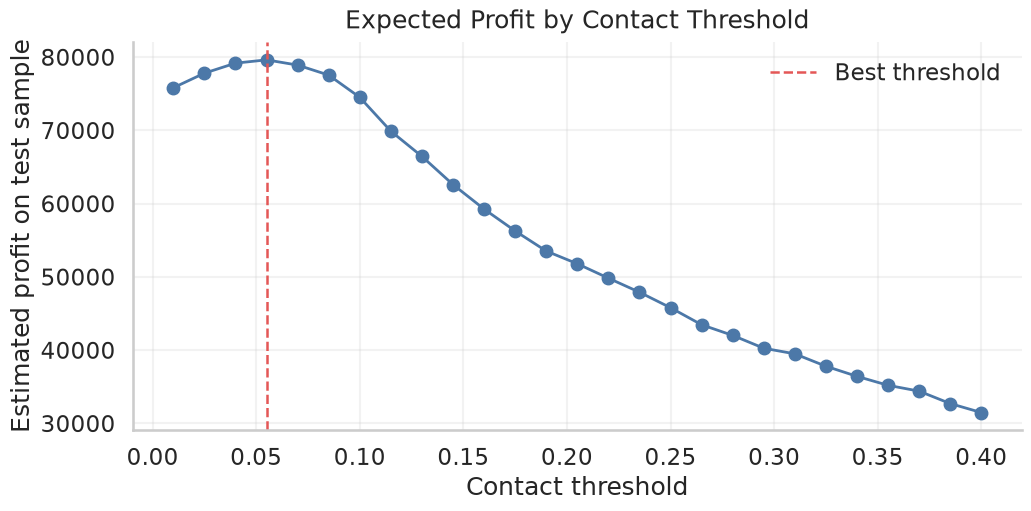

In [11]:
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio root so shared notebook helpers import reliably.
    
    Parameters:
        start: Starting path for the upward project-root search.
    
    Returns:
        A `Path` pointing to the nearest portfolio root that contains `notebooks/_shared`; if no such parent is found, the original starting path is returned.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.real_data import load_uci_bank_marketing, optional_data_note

RUN_REAL_DATA_COMPANION = True

if RUN_REAL_DATA_COMPANION:
    from sklearn.compose import ColumnTransformer
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import train_test_split
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import OneHotEncoder, StandardScaler

    bank = load_uci_bank_marketing()
    y = (bank["y"] == "yes").astype(int)
    X = bank.drop(columns=["duration", "y"])
    categorical = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
    numeric = X.select_dtypes(include=[np.number]).columns.tolist()

    model = Pipeline(
        steps=[
            (
                "preprocess",
                ColumnTransformer(
                    transformers=[
                        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=25), categorical),
                        ("num", StandardScaler(), numeric),
                    ]
                ),
            ),
            ("logit", LogisticRegression(max_iter=2_000)),
        ]
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=2026, stratify=y
    )
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]

    contact_cost = 5.0
    subscription_value = 100.0
    thresholds = np.linspace(0.01, 0.40, 27)
    rows = []
    for threshold in thresholds:
        contact = proba >= threshold
        expected_profit = (subscription_value * y_test.to_numpy() * contact - contact_cost * contact).sum()
        rows.append(
            {
                "threshold": threshold,
                "contact_rate": contact.mean(),
                "expected_profit": expected_profit,
                "subscriptions_captured": y_test.to_numpy()[contact].sum(),
            }
        )
    threshold_table = pd.DataFrame(rows)
    best_row = threshold_table.loc[threshold_table["expected_profit"].idxmax()]

    smart_display(threshold_table.sort_values("expected_profit", ascending=False).head(8).round(3))

    fig, ax1 = plt.subplots(figsize=(10.2, 5.0), constrained_layout=True)
    ax1.plot(
        threshold_table["threshold"],
        threshold_table["expected_profit"],
        marker="o",
        linewidth=2.0,
        color="#4C78A8",
    )
    ax1.axvline(best_row["threshold"], linestyle="--", color="#E45756", linewidth=1.8, label="Best threshold")
    ax1.set_title("Expected Profit by Contact Threshold", pad=10)
    ax1.set_xlabel("Contact threshold")
    ax1.set_ylabel("Estimated profit on test sample")
    ax1.grid(alpha=0.25)
    ax1.legend(frameon=False, loc="upper right")
    sns.despine(fig=fig)
    plt.show()
else:
    optional_data_note(
        "UCI Bank Marketing Dataset",
        "https://archive.ics.uci.edu/dataset/222/bank+marketing",
        "RUN_REAL_DATA_COMPANION",
    )

This companion is a decision-analysis exercise for a specific marketing setup. Change the contact cost, subscription value, or fairness guardrails and the recommended threshold can move. That is exactly why recommendations should state the utility model instead of hiding it behind a model score.


## References

- Ramos, M.-H., van Andel, S. J., & Pappenberger, F. (2013). *Do probabilistic forecasts lead to better decisions?* *Hydrology and Earth System Sciences, 17*(6), 2219-2232. [https://doi.org/10.5194/hess-17-2219-2013](https://doi.org/10.5194/hess-17-2219-2013)
- Raftery, A. E. (2016). *Use and communication of probabilistic forecasts*. *Statistical Analysis and Data Mining: The ASA Data Science Journal, 9*(6), 397-410. [https://doi.org/10.1002/sam.11302](https://doi.org/10.1002/sam.11302)
- Sadatsafavi, M., Lee, T. Y., & Gustafson, P. (2022). *Uncertainty and the value of information in risk prediction modeling*. *Medical Decision Making, 42*(5), 661-671. [https://doi.org/10.1177/0272989X221078789](https://doi.org/10.1177/0272989X221078789)
- Taylor, A. L., Dessai, S., & Bruine de Bruin, W. (2015). *Communicating uncertainty in seasonal and interannual climate forecasts in Europe*. *Philosophical Transactions of the Royal Society A, 373*(2055), 20140454. [https://doi.org/10.1098/rsta.2014.0454](https://doi.org/10.1098/rsta.2014.0454)
- Fundel, V., Fleischhut, N., Herzog, S. M., Göber, M., & Hagedorn, R. (2019). *Promoting the use of probabilistic weather forecasts through a dialogue between scientists, developers and end-users*. *Quarterly Journal of the Royal Meteorological Society, 145*(S1), 210-231. [https://doi.org/10.1002/qj.3482](https://doi.org/10.1002/qj.3482)
